In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
# import seaborn as sns

### Part 1: Parameter analysis function (50 points)

In [56]:
# Reusable functions from Assignment 1
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    TODO: Adapt the SIR model to include deaths

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y  # Note: now 4 compartments
    N = S + I + R + D

    dSdt = -beta * S * I/N
    dIdt = +beta * S * I/N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt


def run_sird_simulation(beta, gamma, mu, N=1000, I0=10, days=150, plot=True):

    # Set up initial conditions with 4 compartments
    S0 = N - I0
    R0_init = 0
    D0 = 0
    y0 = [S0, I0, R0_init, D0]

    # Time points (same as before)
    # Note: days - 1 as the endpoint so that t[i] == i exactly
    t = np.linspace(0, days - 1, days)

    # Solve SIRD equations (adapt from SIR)
    sol = odeint(sird_model, y0, t, args=(beta, gamma, mu))
    S, I, R, D = sol.T

    # Create plot with 4 lines
    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(t, S, 'b-', label='Susceptible', linewidth=2)
        plt.plot(t, I, 'r-', label='Infectious', linewidth=2)
        
        plt.plot(t, R, 'g-', label='Recovered', linewidth=2)
        plt.plot(t, D, 'k-', label='Deceased', linewidth=2)
    
        plt.xlabel('Time (days)')
        plt.ylabel('Population')
        plt.title(f'SIRD Model: β={beta}, γ={gamma}, μ={mu}, R0={beta/(gamma + mu):.2f}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return t, S, I, R, D

In [57]:
# Function implementation
def analyze_recovery_rates(beta, mu, N, I0, simulation_days, gamma_values=(0.05, 0.1, 0.15, 0.2, 0.25)):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float  
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days
    gamma_values : tuple
        Recovery rates to test
    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate
    """

    # initialization
    results = []
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # simulation with different gamma values
    for i, gamma in enumerate(gamma_values):
        t, S, I, R, D = run_sird_simulation(
            beta, gamma, mu, N, I0, simulation_days, plot=False
        )
        peak_idx = np.argmax(I)

        # in case the curve would not peak write out Nan for peak-related values
        if peak_idx == 0: # no peak as I never rose above its starting value
            results.append({
                "gamma": gamma,
                "R0": beta / gamma,
                "peak_infected": None,
                "peak_day": None,
                "total_deaths": D[-1],
        })
        # otherwise write out actual real peak values
        else: 
            results.append({
                "gamma": gamma,
                "R0": beta / gamma,
                "peak_infected": I[peak_idx],
                "peak_day": t[peak_idx],
                "total_deaths": D[-1],
            })
    
        ax.plot(t, I, linewidth=2,
                    label=f"γ={gamma:.2f} (R₀={beta/gamma:.1f})")        

    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Infectious individuals")
    ax.set_title(f"Effect of recovery rate on epidemic dynamics (β={beta}, μ={mu})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # build a pandas dataframe from the list of dictionaries
    df = pd.DataFrame(
        results,
        columns=["gamma", "R0", "peak_infected", "peak_day", "total_deaths"],
    )
    df["R0"] = df["R0"].round(2)
    df["peak_infected"] = df["peak_infected"].round(0)
    df["peak_day"] = df["peak_day"].round(0)
    df["total_deaths"] = df["total_deaths"].round(0)
    return df

### Part 2: Scenario comparison (30 points)

Scenario A — High Transmission


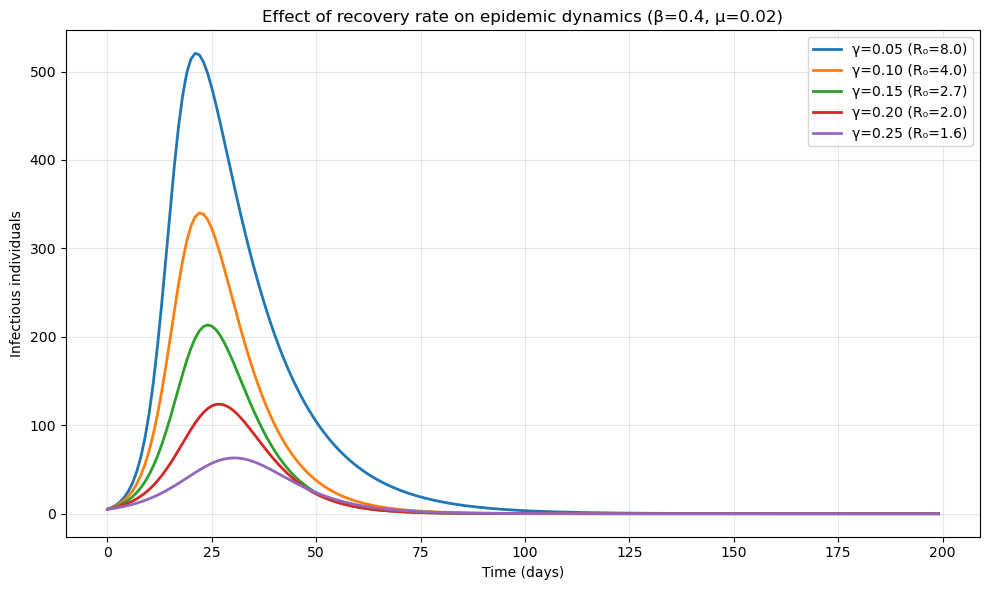

Scenario B — Low Transmission


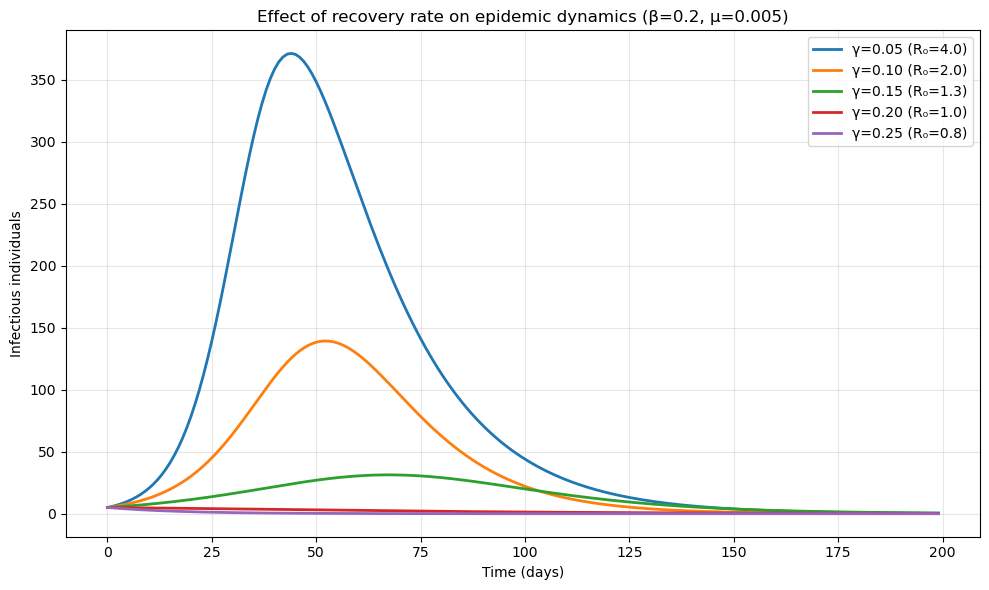

In [58]:
# Run 2 scenarios and create comparative visualizations
print("Scenario A — High Transmission")
results_a = analyze_recovery_rates(
    beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200
)

print("Scenario B — Low Transmission")
results_b = analyze_recovery_rates(
    beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200
)

In [59]:
print("Scenario A — High Transmission (β=0.4, μ=0.02)")
display(results_a)

print("Scenario B — Low Transmission (β=0.2, μ=0.005)")
display(results_b)

Scenario A — High Transmission (β=0.4, μ=0.02)


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,8.00,521.0,21.0,285.0
1,0.10,4.00,340.0,22.0,160.0
2,0.15,2.67,213.0,24.0,103.0
3,0.20,2.00,124.0,27.0,67.0
4,0.25,1.60,63.0,30.0,43.0


Scenario B — Low Transmission (β=0.2, μ=0.005)


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,4.00,371.0,44.0,88.0
1,0.10,2.00,139.0,52.0,37.0
2,0.15,1.33,31.0,67.0,14.0
3,0.20,1.00,NaN,NaN,2.0
4,0.25,0.80,NaN,NaN,0.0


### Which scenario is worse for public health and why

In [60]:
# Print out key parameters
scenarios = [("A: High transmission", 0.4, 0.02),
             ("B: Low transmission", 0.2, 0.005)]
N, I0, days = 1000, 5, 200

for label, beta, mu in scenarios:
    print(f"\n{label}  (β={beta}, μ={mu})")
    for gamma in (0.05, 0.25):
        t, S, I, R, D = run_sird_simulation(beta, gamma, mu, N, I0, days, plot=False)

        peak_idx = np.argmax(I)
        total_infected = N - S[-1]
        cfr = D[-1] / total_infected * 100

        print(f"  γ = {gamma}")
        print(f"    R0 (Beta/(gamma+mu))                     : {beta/(gamma+mu):.2f}")
        print(f"    Recovered                                : {R[-1]:.0f}")
        print(f"    Total infected                           : {total_infected:.0f} ({total_infected/N*100:.1f}%)")
        print(f"    Deaths                                   : {D[-1]:.0f}")
        print(f"    Case Fatality Rate                       : {cfr:.1f}% ") 
        if peak_idx == 0:
            print(f"    Peak infections                          : none (R0 < 1)")
        else:
            print(f"    Peak infections                          : {I[peak_idx]:.0f} on day {t[peak_idx]:.0f}")
            infected_by_peak = N - S[peak_idx]
            print(f"    Infected by the peak                     : {infected_by_peak:.0f} ({infected_by_peak/N*100:.1f}%)")
            print(f"    S at peak                                : {S[peak_idx]:.0f} (theory N/R0 = {N/(beta/(gamma+mu)):.0f})")
        
        print(f"    Infectious at day {days}                    : {I[-1]:.3f}")        


A: High transmission  (β=0.4, μ=0.02)
  γ = 0.05
    R0 (Beta/(gamma+mu))                     : 5.71
    Recovered                                : 712
    Total infected                           : 997 (99.7%)
    Deaths                                   : 285
    Case Fatality Rate                       : 28.6% 
    Peak infections                          : 521 on day 21
    Infected by the peak                     : 815 (81.5%)
    S at peak                                : 185 (theory N/R0 = 175)
    Infectious at day 200                    : 0.004
  γ = 0.25
    R0 (Beta/(gamma+mu))                     : 1.48
    Recovered                                : 534
    Total infected                           : 576 (57.6%)
    Deaths                                   : 43
    Case Fatality Rate                       : 7.4% 
    Peak infections                          : 63 on day 30
    Infected by the peak                     : 319 (31.9%)
    S at peak                               

Scenario B has lower transmission and lower death rate. It is a better scenario in 2 different frameworks: R0>1 and R0<1.
When R0<1 (Scenario B at gamma = 0.25,R0 = 0.78), there is no epidemic: 22 people infected, no peak, no meaningful mortality. This is never the case under scenario A, where with the highest recovery rate R0 reaches 1.48 and 58% of population gets infected.
When R0>1 A is a much worse scenario. At gamma = 0.05: 997 vs. 971 infected, 521 vs. 371 peak, and 285 vs. 88 deaths. The only "benefit" of the A scenario in comparison with B is duration: compare peak on day 44 under Scenario B with day 21 under Scenario A.
It is worth mentioning that with gamma = 0.05, only under Scenario A is the epidemic finished within the given time window. Under Scenario B, it is going on with I ~0.346. So, 88 is not the final number of deaths.

### Part 3: Policy recommendations (20 points)

#### 3.1 Parameter impact analysis

(Below the example of scenario A with Beta of 0.4 and mu of 0.02 is considered).

**Gamma:** Gamma is one of the contributors to 1/(gamma + mu) - mean number of days an individual is infectious. With the same mu = 0.02, at gamma 0.05 the mean duration is 14 days, while at gamma 0.25 it is 3.7 days. 

**Beta:** with Beta held unchanged at 0.4, at gamma of 0.05 a sick person would transmit the disease to 5.7 people; at gamma of 0.25, to 1.5 people. 

**Mu:** with the mu held unchanged, Case Fatality Rate with gamma of 0.05 will be 28.6% vs. 7.4% with gamma of 0.25. This results at much lower mortality with higher gamma.

**R0:** at gamma 0.05 it is 5.7 going down to 1.48 as gamma moves up to 0.25.

This results in a reduction in the **peak of infections** from 521 to 63. A shorter infectious period means fewer transmissions per case: with beta held constant at 0.4 one person would infect 5.7 others with gamma 0.05 and 1.5 persons on average with gamma 0.25 (that is R0). Since the epidemic peak occurs at the point of equilibrium (N/R0), this change of gamma moves the peak from 82.5% of the population infected at gamma = 0.05 to 32.4% at gamma = 0.25. **Total deaths** fall steeply with the change of gamma (521 to 63 in our scenario) because gamma influences both the transmission rate and a chance of death of infected people. The Case Fatality Rate (mu/(gamma + mu)) drops from 28.6% to 7.4% (there are fewer days a sick person is exposed to the risk of death). **Duration** does not fall monotonically. Faster recovery rates speed up the decline as sick people are sick for a shorter period, but lower R0 also slows down the epidemic and the peak is reached later. These are two competing forces and from 0.05 up to gamma ~ 0.15 the first force wins and the epidemic lasts less, but after that the second force wins and epidemic lasts longer. 

#### 3.2 Intervention analysis

In [61]:
beta, mu, N, I0, days = 0.4, 0.02, 1000, 5, 400

rows = []
for base in (0.05, 0.10, 0.15, 0.20, 0.25):
    new = base * 1.5
    _, S_before, _, _, D_before = run_sird_simulation(beta, base, mu, N, I0, days, plot=False)
    _, S_after, _, _, D_after = run_sird_simulation(beta, new, mu, N, I0, days, plot=False)

    attack_before = (N - S_before[-1]) / N
    attack_after = (N - S_after[-1]) / N
    cfr_before = mu / (base + mu)
    cfr_after = mu / (new + mu)

    rows.append({
        "gamma before": base,
        "gamma after": new,
        "days inf. before": 1 / (base + mu),
        "days inf. after": 1 / (new + mu),
        "R0 before": beta / (base + mu),
        "R0 after": beta / (new + mu),
        "attack % before": attack_before * 100,
        "attack % after": attack_after * 100,
        "CFR % before": cfr_before * 100,
        "CFR % after": cfr_after * 100,
        "deaths before": D_before[-1],
        "deaths after": D_after[-1],
        "reduction %": (D_before[-1] - D_after[-1]) / D_before[-1] * 100,
    })

display(pd.DataFrame(rows).round(2))

,gamma before,gamma after,days inf. before,days inf. after,R0 before,R0 after,attack % before,attack % after,CFR % before,CFR % after,deaths before,deaths after,reduction %
0,0.05,0.08,14.29,10.53,5.71,4.21,99.67,98.42,28.57,21.05,284.76,207.20,27.23
1,0.10,0.15,8.33,5.88,3.33,2.35,95.94,87.22,16.67,11.76,159.89,102.61,35.83
2,0.15,0.22,5.88,4.08,2.35,1.63,87.22,66.28,11.76,8.16,102.61,54.11,47.27
3,0.20,0.30,4.55,3.12,1.82,1.25,74.17,38.53,9.09,6.25,67.42,24.08,64.28
4,0.25,0.38,3.70,2.53,1.48,1.01,57.64,10.88,7.41,5.06,42.69,5.51,87.09


If an intervention could increase recovery rate by 50%, this would have the following impact:

- infectious period will get shorter;
- transmission (R0) would go down;
- attack rate (percentage of those eventually infected) will reduce
- Case Fatality Rate will go down 

Deaths = N * attack rate * CFR
The effect is substantial reduction in the number of deaths growing with the increase in the original recovery rate. For example at a baseline of gamma = 0.1: infectious period goes down from 8.3 to 5.9 days, Ro falls from 3.33 to 2.35, attack rate reduces from 95.9% to 87.2%, CFR from 16.7% to 11.8%, which results in the decrease in the number of deaths from 160 to 103 (a 35.8% decrease). This reduction is mainly driven by the attack rate as the relative change in CFR stays roughly constant across different values of gamma. 

#### 3.3 Real-world application


**Testing and isolation** of infected people is one measure that could increase recovery rates as it would reduce the transmission of the disease. Isolation is mathematically equivalent to raising gamma and thus the impact analysis from the previous question is also an answer to this question. A 50% increase in gamma, say, from 0.1 to 0.15 could be explained by an extra factor of 0.05, i.e. isolating detected disease cases for 1/0.05 = 20 days. This is longer compared to the recovery with this gamma (8.3 days) and reduces the risk of isolated people infecting others practically to 0. For this example, the deaths reduced by 35.8%. In practice, this is a measure which is difficult to implement because it faces very negative reactions from those affected and infected people can also be contagious before the disease was detected.  